# Experiment 1 vs Experiment 2 - W-estimate skill comparison

Overlays the summary figures from **experiment_1** and **experiment_2**, which are
identical except that experiment_2 passes `extrapolate_to_surface=True` to
`compute_w_planefit` (so its integrated w reaches the surface; its depth grid runs
0 -> -70 m instead of -8 -> -70 m).

Reproduces Figures **2a-2d** (skill vs array width) and **5a-5d** (skill vs depth)
from `experiment_*/summary.ipynb`, plotting both experiments on the same axes.

Encoding used throughout:

- **colour** = the within-method knob (cell centre latitude / gliders-per-cell for
  2a-c / 5a-c; **cell shape** - diamond / hexagon / square - for 2d / 5d).
- **linestyle + marker fill** = experiment: **exp1 = solid, filled marker**;
  **exp2 = dashed, open marker**.
- **marker shape** (2d / 5d only) = cell height (o = 1deg tall, ^ = 2deg tall).

Everything is read from `experiment_*/data/`; figures are written to this folder.
Run in place after both experiments have populated their `data/`.

In [1]:
import os, sys
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

REPO = "/home/edavenport/analysis/tpose24-osse"
sys.path.insert(0, REPO)
import osse_tools as ot

OUTDIR = os.path.join(REPO, "compare_exp_1_2"); os.makedirs(OUTDIR, exist_ok=True)
plt.rcParams["figure.dpi"] = 120

EXP_ROOT = {1: os.path.join(REPO, "experiment_1"), 2: os.path.join(REPO, "experiment_2")}
M = {e: pd.read_csv(os.path.join(EXP_ROOT[e], "data", "metrics.csv")) for e in (1, 2)}

# experiment_2 == experiment_1 but with extrapolate_to_surface=True in compute_w_planefit
EXP_STYLE = {
    1: dict(ls="-",  fill=True,  lbl="exp1 (no surface extrap)"),
    2: dict(ls="--", fill=False, lbl="exp2 (extrap to surface)"),
}

def load_cell(exp, row):
    """Open the saved w_est/w_model/bias arrays for one metrics row of an experiment."""
    return xr.open_dataset(os.path.join(EXP_ROOT[exp], row.nc_path))

def mfc(exp, color):
    """Marker face colour: filled (exp1) or open/white (exp2)."""
    return color if EXP_STYLE[exp]["fill"] else "white"

def exp_handles():
    """Legend handles distinguishing the two experiments by line style only
    (marker fill is a redundant cue on the data lines; here the solid-vs-dashed
    line is what the reader needs to see)."""
    return [Line2D([0], [0], color="0.3", ls=EXP_STYLE[e]["ls"], lw=1.9,
                   label=EXP_STYLE[e]["lbl"]) for e in (1, 2)]

# longer legend handles so the solid-vs-dashed line style is clearly visible
EXP_LEG = dict(title="experiment", fontsize=8, loc="best", handlelength=3.2)

print({e: len(M[e]) for e in (1, 2)})

{1: 96, 2: 96}


In [2]:
# Style dictionaries and geometry-panel helpers, copied verbatim from
# experiment_1/summary.ipynb so the comparison figures match the originals.
LAT_COLORS = {
    -1.5: "#08306b", -1.0: "#2171b5", -0.5: "#6baed6",
     0.0: "#111111",
     0.5: "#fb6a4a",  1.0: "#cb181d",  1.5: "#67000d",
}
GLIDER_COLORS = {2: "#440154", 4: "#21918c", 6: "#9fda3a"}
# equator single-cell: colour = SHAPE, marker = cell HEIGHT (linestyle is reserved
# for the experiment here: solid = exp1, dashed = exp2).
EQS_SHAPE_COLOR = {"diamond": "#1f77b4", "hexagon": "#2ca02c", "square": "#d62728"}
EQS_HEIGHT_MK   = {1.0: "o", 2.0: "^"}           # cell_height_deg -> marker
EQS_META = {                                     # pattern -> (shape, height_deg)
    "equator_1deg":    ("diamond", 1.0), "equator_2deg":    ("diamond", 2.0),
    "equator_hex1deg": ("hexagon", 1.0), "equator_hex2deg": ("hexagon", 2.0),
    "equator_sq1deg":  ("square",  1.0), "equator_sq2deg":  ("square",  2.0),
}
EQS_STYLE = {pat: dict(color=EQS_SHAPE_COLOR[sh], mk=EQS_HEIGHT_MK[h],
                       lbl=f"{h:g}deg {sh}", shape=sh, height=h)
             for pat, (sh, h) in EQS_META.items()}
EQS_PATS = ["equator_1deg", "equator_2deg", "equator_hex1deg", "equator_hex2deg",
            "equator_sq1deg", "equator_sq2deg"]

def _lat_lbl(v): return f"{v:+.1f}"

def _hull_poly(pts):
    pts = np.array(pts, float)
    c = pts.mean(0)
    order = np.argsort(np.arctan2(pts[:, 1] - c[1], pts[:, 0] - c[0]))
    p = pts[order]
    return np.vstack([p, p[0]])

def _layout_legend(ax, loc="upper right"):
    ax.plot([], [], marker="s", ls="", color="0.55", ms=6, label="mooring")
    ax.plot([], [], marker="o", ls="", color="0.4", mec="k", mew=0.3, ms=6, label="glider")
    ax.legend(fontsize=7, loc=loc)

def _stacked_cells_panel(ax, cells, half, title, off_demo=0.5):
    vlats = sorted({c + s * half for c in cells for s in (-1, 1)} | set(cells))
    moor = [v for v in vlats if abs(v - round(v)) < 1e-9]
    ax.plot([0, 0], [min(vlats), max(vlats)], color="0.8", lw=0.8, zorder=1)
    ax.plot([0] * len(moor), moor, marker="s", ls="", color="0.55", ms=6, zorder=3)
    for c in cells:
        col = LAT_COLORS[c]
        ax.plot([-off_demo, off_demo], [c, c], marker="o", ls="", color=col,
                ms=6, mec="k", mew=0.3, zorder=4)
        poly = _hull_poly([(0, c + half), (off_demo, c), (0, c - half), (-off_demo, c)])
        ax.plot(poly[:, 0], poly[:, 1], "-", color=col, lw=1.8, zorder=2)
        ax.fill(poly[:, 0], poly[:, 1], color=col, alpha=0.07, zorder=0)
        ax.text(off_demo + 0.16, c, f"{c:+.1f}", va="center", ha="left", fontsize=7, color=col)
    _layout_legend(ax, loc="upper right")
    ax.set_aspect("equal"); ax.set_xlim(-1.0, 2.0)
    ax.set_ylim(min(vlats) - 0.4, max(vlats) + 0.4)
    ax.set_xticks([]); ax.set_yticks(moor); ax.set_ylabel("lat (deg)")
    ax.set_title(title); ax.grid(alpha=0.2, axis="y")

def _density_geometry_panel(ax, off_demo=0.5):
    rows_by_ng = {2: [0.5], 4: [0.25, 0.75], 6: [0.25, 0.5, 0.75]}
    for i, ng in enumerate((2, 4, 6)):
        xc, col = i * 2.0, GLIDER_COLORS[ng]
        ax.plot([xc, xc], [0, 1], color="0.8", lw=0.8, zorder=1)
        ax.plot([xc, xc], [0, 1], marker="s", ls="", color="0.55", ms=6, zorder=3)
        gl = [(xc + s * off_demo, r) for r in rows_by_ng[ng] for s in (-1, 1)]
        ax.plot([p[0] for p in gl], [p[1] for p in gl], marker="o", ls="",
                color=col, ms=6, mec="k", mew=0.3, zorder=4)
        poly = _hull_poly([(xc, 0), (xc, 1)] + gl)
        ax.plot(poly[:, 0], poly[:, 1], "-", color=col, lw=1.8, zorder=2)
        ax.fill(poly[:, 0], poly[:, 1], color=col, alpha=0.08, zorder=0)
        ax.text(xc, -0.4, f"{ng} gliders", ha="center", va="top", fontsize=8, color=col)
    _layout_legend(ax)
    ax.set_aspect("equal"); ax.set_xlim(-1.0, 5.1); ax.set_ylim(-0.8, 1.5)
    ax.set_xticks([]); ax.set_yticks([0, 0.5, 1]); ax.set_ylabel("lat (deg)")
    ax.set_title("glider layout (offset = 0.5deg)")
    ax.grid(alpha=0.2, axis="y")

def _draw_equator_cell(ax, xc, shape, half, color, label, off=0.5):
    if shape == "diamond":
        verts = [(0, half), (off, 0), (0, -half), (-off, 0)]
    elif shape == "hexagon":
        mid = half / 2.0
        verts = [(0, half), (off, mid), (off, -mid), (0, -half), (-off, -mid), (-off, mid)]
    else:                                       # square (box): 4 corner gliders
        verts = [(off, half), (off, -half), (-off, -half), (-off, half)]
    # free real moorings on the lon line within the cell's lat span (incl. centre)
    line_moor = [(0.0, ml) for ml in (-2, -1, 0, 1, 2) if -half - 1e-9 <= ml <= half + 1e-9]
    pts = verts + [p for p in line_moor if p not in verts]
    is_moor = lambda x, y: abs(x) < 1e-9 and abs(y - round(y)) < 1e-9
    ax.plot([xc, xc], [-half, half], color="0.8", lw=0.8, zorder=1)
    mo = [(xc + x, y) for x, y in pts if is_moor(x, y)]
    gl = [(xc + x, y) for x, y in pts if not is_moor(x, y)]
    ax.plot([p[0] for p in mo], [p[1] for p in mo], marker="s", ls="",
            color="0.55", ms=6, zorder=3)
    ax.plot([p[0] for p in gl], [p[1] for p in gl], marker="o", ls="",
            color=color, ms=6, mec="k", mew=0.3, zorder=4)
    poly = _hull_poly([(xc + x, y) for x, y in verts])
    ax.plot(poly[:, 0], poly[:, 1], "-", color=color, lw=1.8, zorder=2)
    ax.fill(poly[:, 0], poly[:, 1], color=color, alpha=0.08, zorder=0)
    ax.text(xc, -1.45, label, ha="center", va="top", fontsize=7.5, color=color)

def _equator_single_geometry(ax):
    layout = [("diamond", 0.5), ("diamond", 1.0),
              ("hexagon", 0.5), ("hexagon", 1.0),
              ("square",  0.5), ("square",  1.0)]
    for i, (shape, half) in enumerate(layout):
        _draw_equator_cell(ax, i * 2.0, shape, half, EQS_SHAPE_COLOR[shape],
                           f"{2 * half:g}deg {shape}")
    _layout_legend(ax, loc="upper right")
    ax.set_aspect("equal"); ax.set_xlim(-1.0, 11.0); ax.set_ylim(-1.9, 1.5)
    ax.set_xticks([]); ax.set_yticks([-1, 0, 1]); ax.set_ylabel("lat (deg)")
    ax.set_title("cell geometry (offset = 0.5deg)")
    ax.grid(alpha=0.2, axis="y")

## Figures 2a-2d - skill vs array width, exp1 vs exp2

One figure per method. Panels 1-2: normalized error and correlation vs glider
offset, with exp1 (solid, filled) and exp2 (dashed, open) overlaid; colour is the
within-method knob. Panel 3: the fixed platform layout (identical for both
experiments).

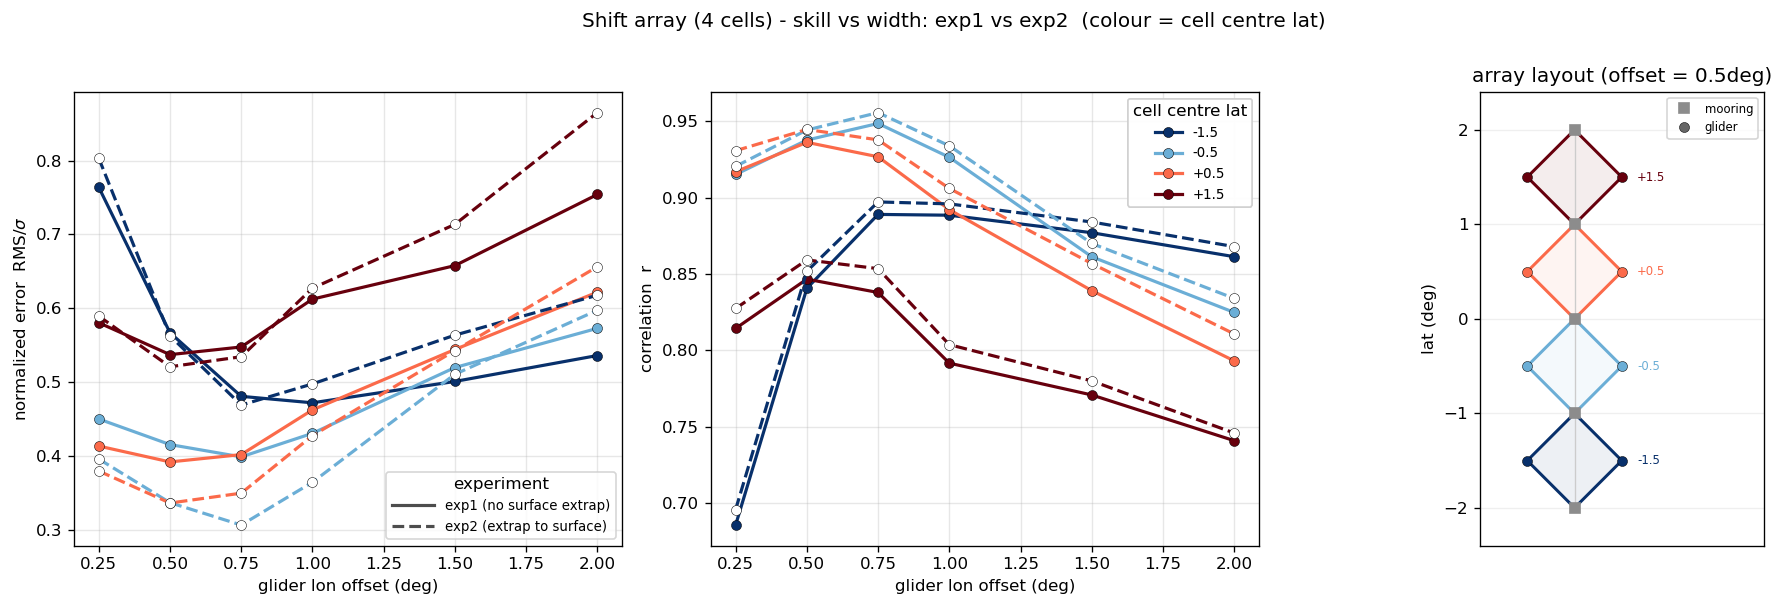

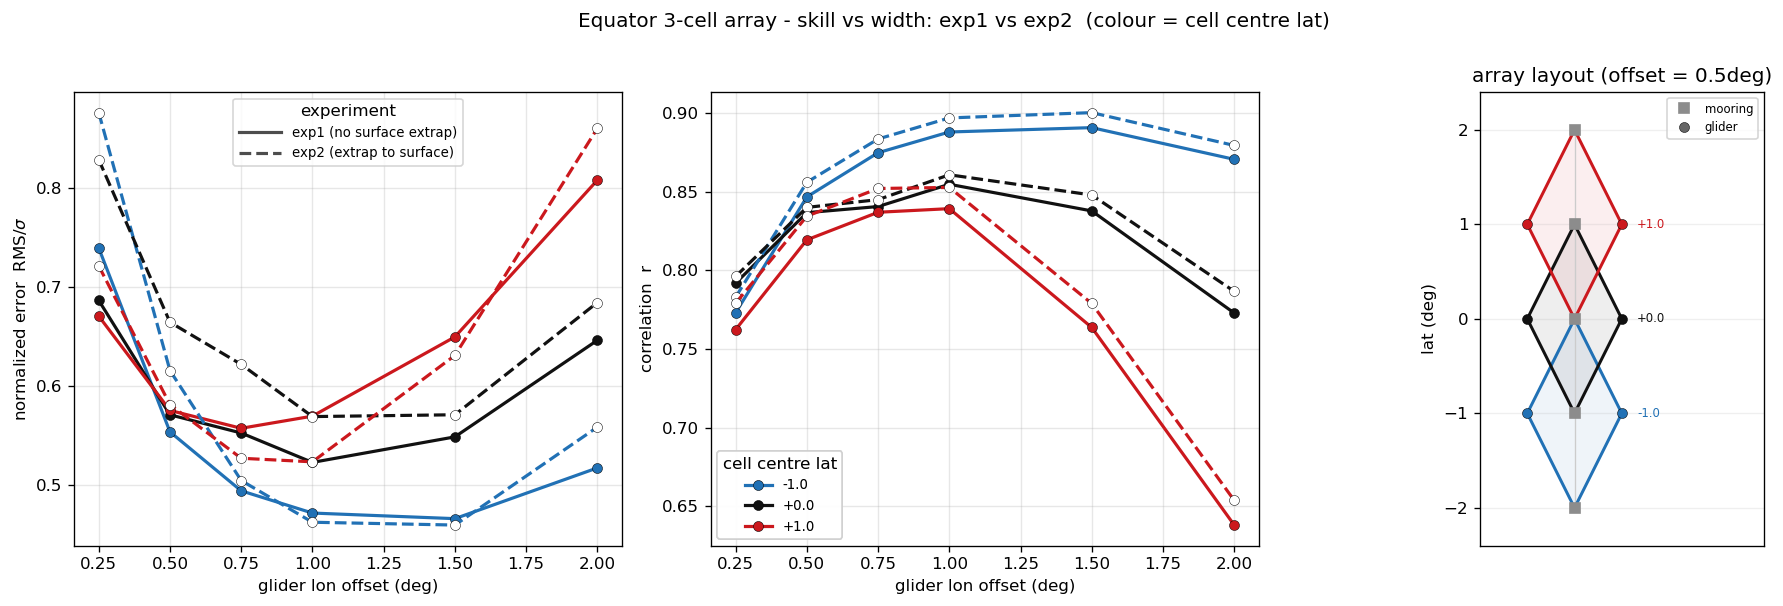

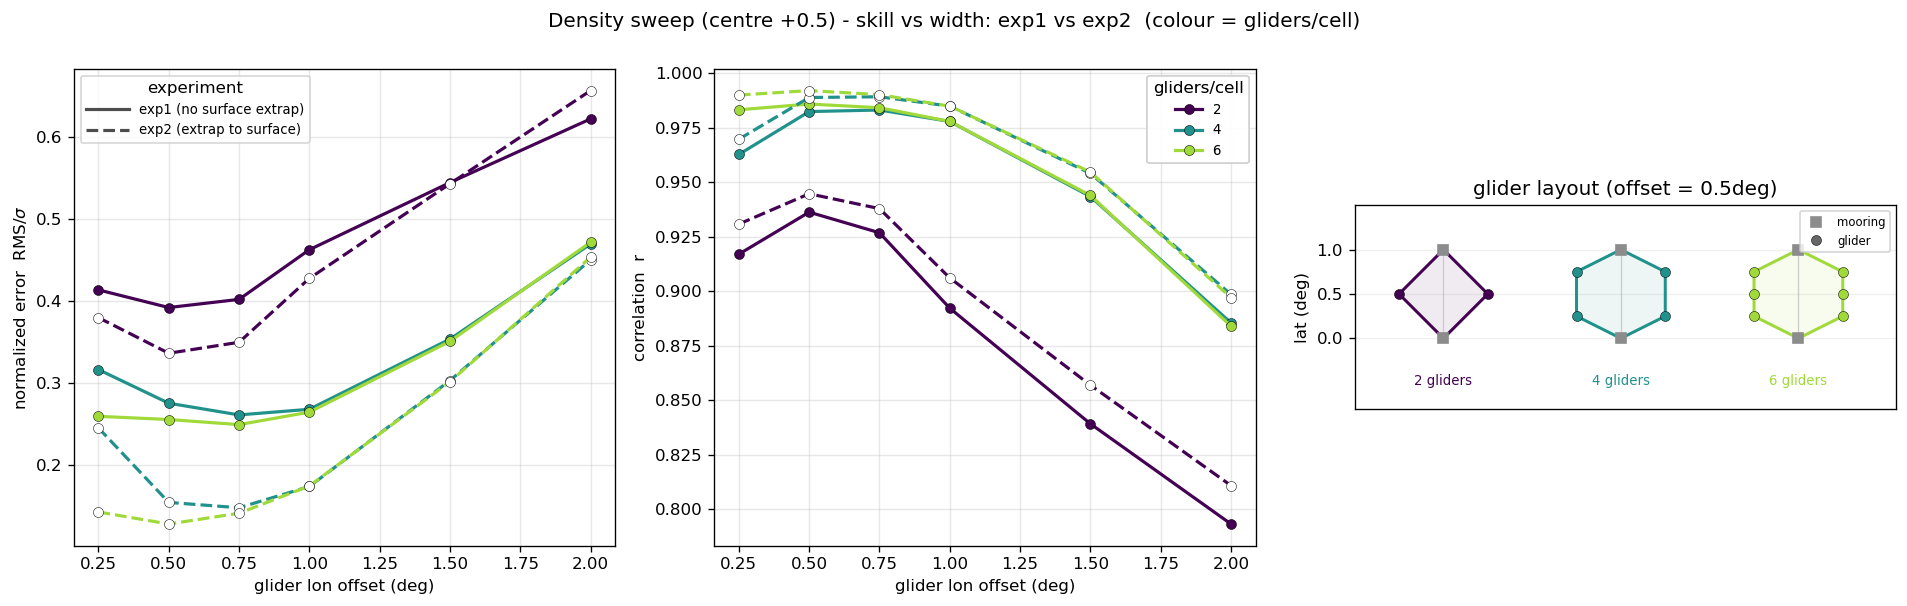

In [3]:
# Figures 2a/2b/2c - single-key methods via a generic loop; both experiments overlaid.
PANELS = [
    ("2a_shift", "Shift array (4 cells)", lambda mm: mm.family == "shift",
     "center_lat", LAT_COLORS, "cell centre lat", _lat_lbl,
     lambda ax: _stacked_cells_panel(ax, [-1.5, -0.5, 0.5, 1.5], 0.5,
                                     "array layout (offset = 0.5deg)")),
    ("2b_equator3cell", "Equator 3-cell array", lambda mm: mm.pattern == "equator_3cell",
     "center_lat", LAT_COLORS, "cell centre lat", _lat_lbl,
     lambda ax: _stacked_cells_panel(ax, [-1.0, 0.0, 1.0], 1.0,
                                     "array layout (offset = 0.5deg)")),
    ("2c_density", "Density sweep (centre +0.5)", lambda mm: mm.family == "density",
     "n_gliders_cell", GLIDER_COLORS, "gliders/cell", lambda v: f"{int(v)}",
     _density_geometry_panel),
]
for tag, title, maskfn, key, cmap, leg_title, lbl, geom in PANELS:
    keys = sorted(M[1][maskfn(M[1])][key].unique())
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    for exp in (1, 2):
        st = EXP_STYLE[exp]; d = M[exp][maskfn(M[exp])]
        for kv in keys:
            dd = d[d[key] == kv].drop_duplicates("width").sort_values("width")
            for ax, col_y in ((axes[0], "norm_rms"), (axes[1], "corr")):
                ax.plot(dd.width, dd[col_y], ls=st["ls"], marker="o", color=cmap[kv],
                        lw=1.9, ms=6, mec="k", mew=0.3, mfc=mfc(exp, cmap[kv]))
    axes[0].set_ylabel(r"normalized error  RMS/$\sigma$")
    axes[1].set_ylabel("correlation  r")
    for ax in axes[:2]:
        ax.set_xlabel("glider lon offset (deg)"); ax.grid(alpha=0.3)
    col_handles = [Line2D([0], [0], color=cmap[kv], marker="o", mec="k", mew=0.3,
                          lw=1.9, label=lbl(kv)) for kv in keys]
    leg1 = axes[1].legend(handles=col_handles, title=leg_title, fontsize=8, loc="best")
    axes[1].add_artist(leg1)
    axes[0].legend(handles=exp_handles(), **EXP_LEG)
    geom(axes[2])
    fig.suptitle(f"{title} - skill vs width: exp1 vs exp2  (colour = {leg_title})", y=1.0)
    fig.tight_layout()
    fig.savefig(os.path.join(OUTDIR, f"fig{tag}_compare.png"), dpi=150, bbox_inches="tight")
    plt.show()

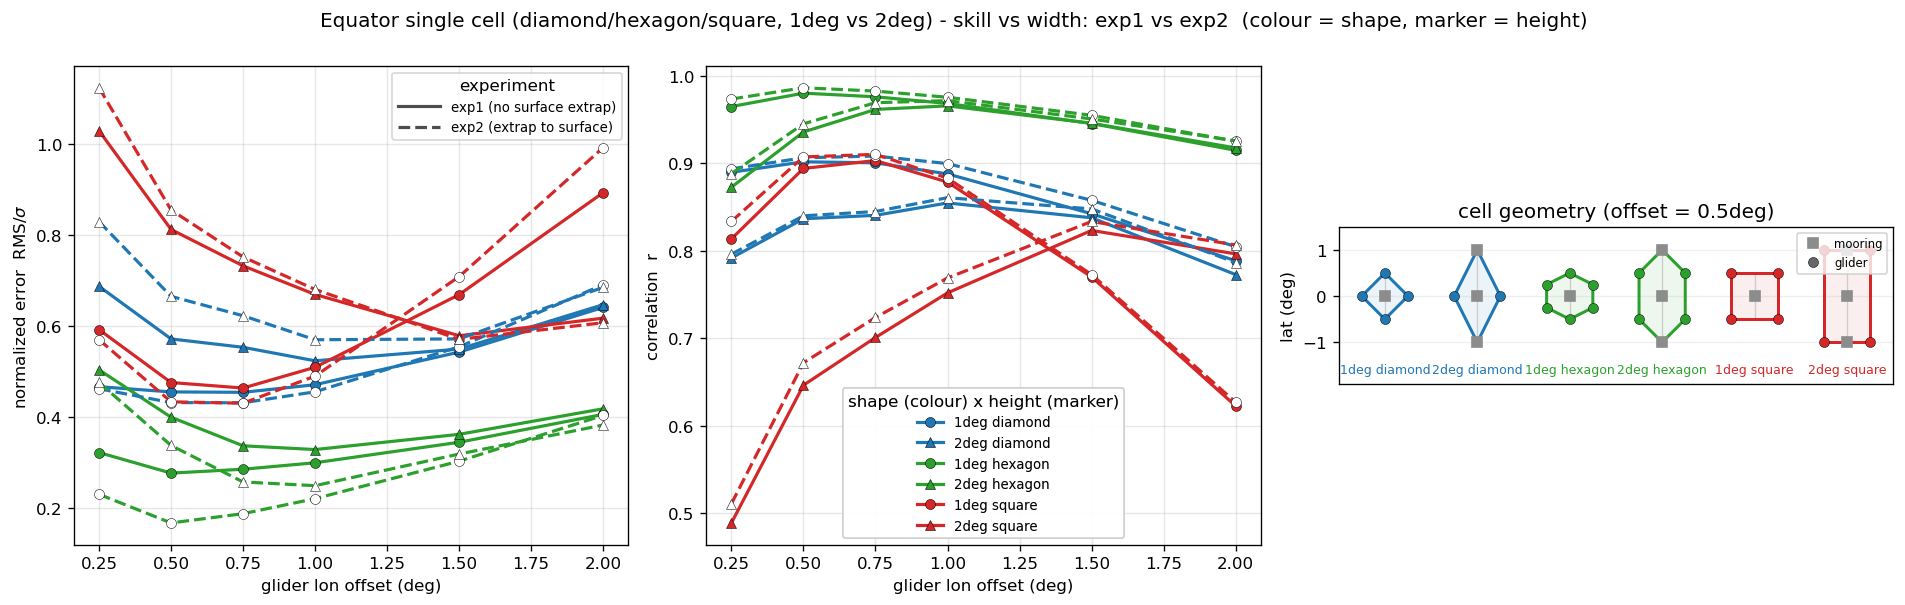

In [4]:
# Figure 2d - equator single cell, diamond/hexagon/square x 1deg/2deg; both experiments.
# colour = shape, marker = cell height, linestyle/fill = experiment.
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for exp in (1, 2):
    st = EXP_STYLE[exp]
    for pat in EQS_PATS:
        s = EQS_STYLE[pat]
        dd = M[exp][M[exp].pattern == pat].sort_values("width")
        if dd.empty:
            continue
        for ax, col_y in ((axes[0], "norm_rms"), (axes[1], "corr")):
            ax.plot(dd.width, dd[col_y], ls=st["ls"], marker=s["mk"], color=s["color"],
                    lw=1.9, ms=6, mec="k", mew=0.3, mfc=mfc(exp, s["color"]))
axes[0].set_ylabel(r"normalized error  RMS/$\sigma$")
axes[1].set_ylabel("correlation  r")
for ax in axes[:2]:
    ax.set_xlabel("glider lon offset (deg)"); ax.grid(alpha=0.3)
shape_handles = [Line2D([0], [0], color=EQS_STYLE[p]["color"], marker=EQS_STYLE[p]["mk"],
                        mec="k", mew=0.3, lw=1.9, label=EQS_STYLE[p]["lbl"]) for p in EQS_PATS]
leg1 = axes[1].legend(handles=shape_handles, title="shape (colour) x height (marker)", fontsize=8, loc="best")
axes[1].add_artist(leg1)
axes[0].legend(handles=exp_handles(), **EXP_LEG)
_equator_single_geometry(axes[2])
fig.suptitle("Equator single cell (diamond/hexagon/square, 1deg vs 2deg) - skill vs width: "
             "exp1 vs exp2  (colour = shape, marker = height)", y=1.0)
fig.tight_layout()
fig.savefig(os.path.join(OUTDIR, "fig2d_equator_single_compare.png"), dpi=150, bbox_inches="tight")
plt.show()

## Figures 5a-5d - skill vs depth, exp1 vs exp2

Depth-resolved skill at a fixed glider offset (`DEPTH_WIDTH = 1.0deg`), one figure
per method. Panels: normalized error, correlation, and absolute RMS (coloured) vs
signal std (grey). exp1 = solid/filled, exp2 = dashed/open. Because exp2
extrapolates to the surface, its profiles extend above -8 m up to 0 m.

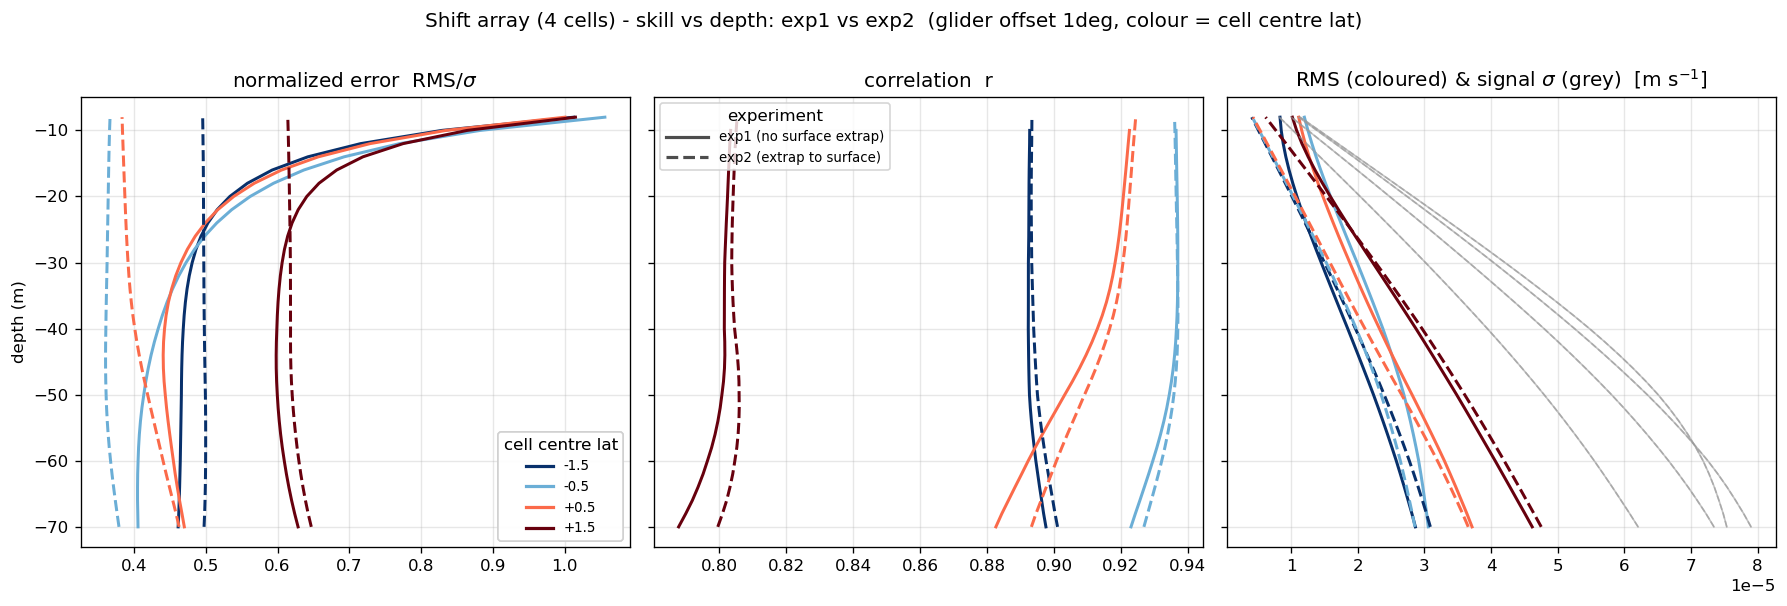

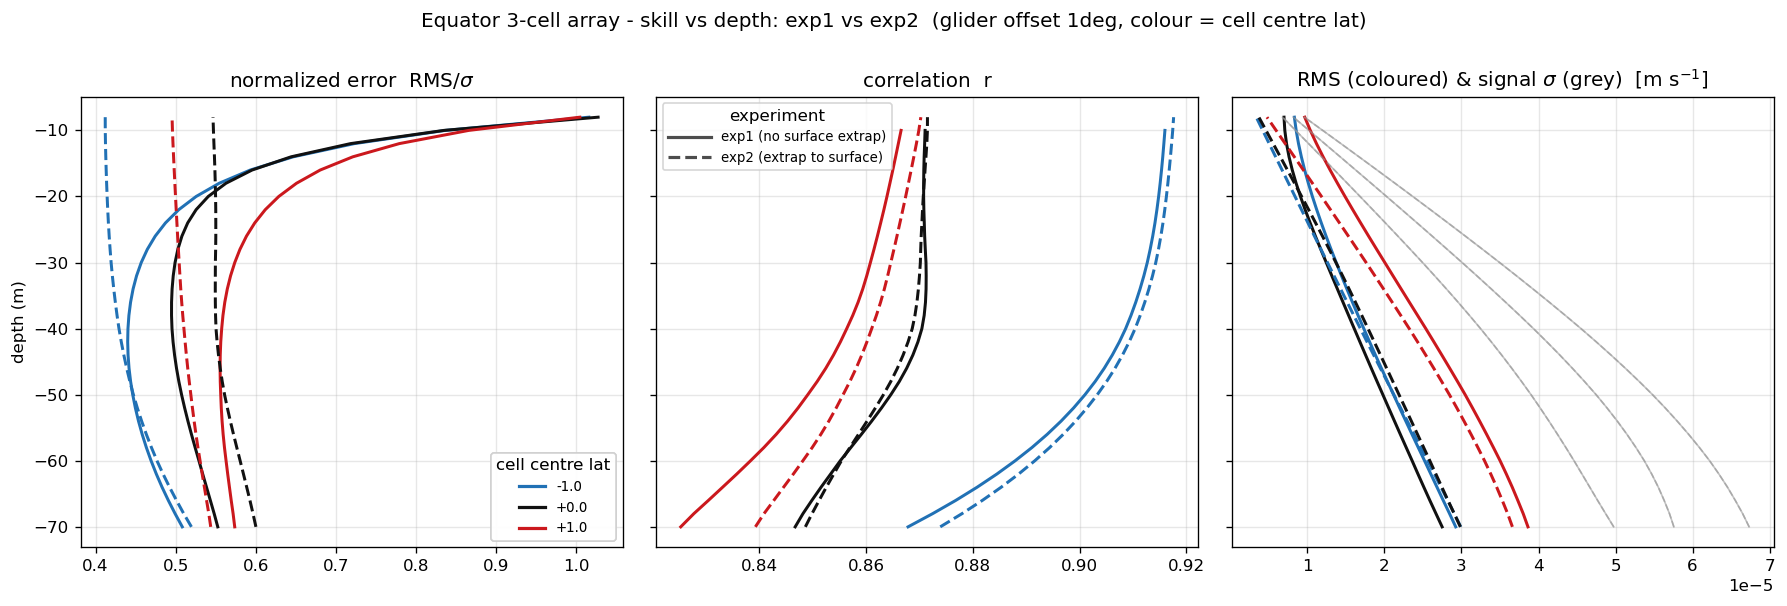

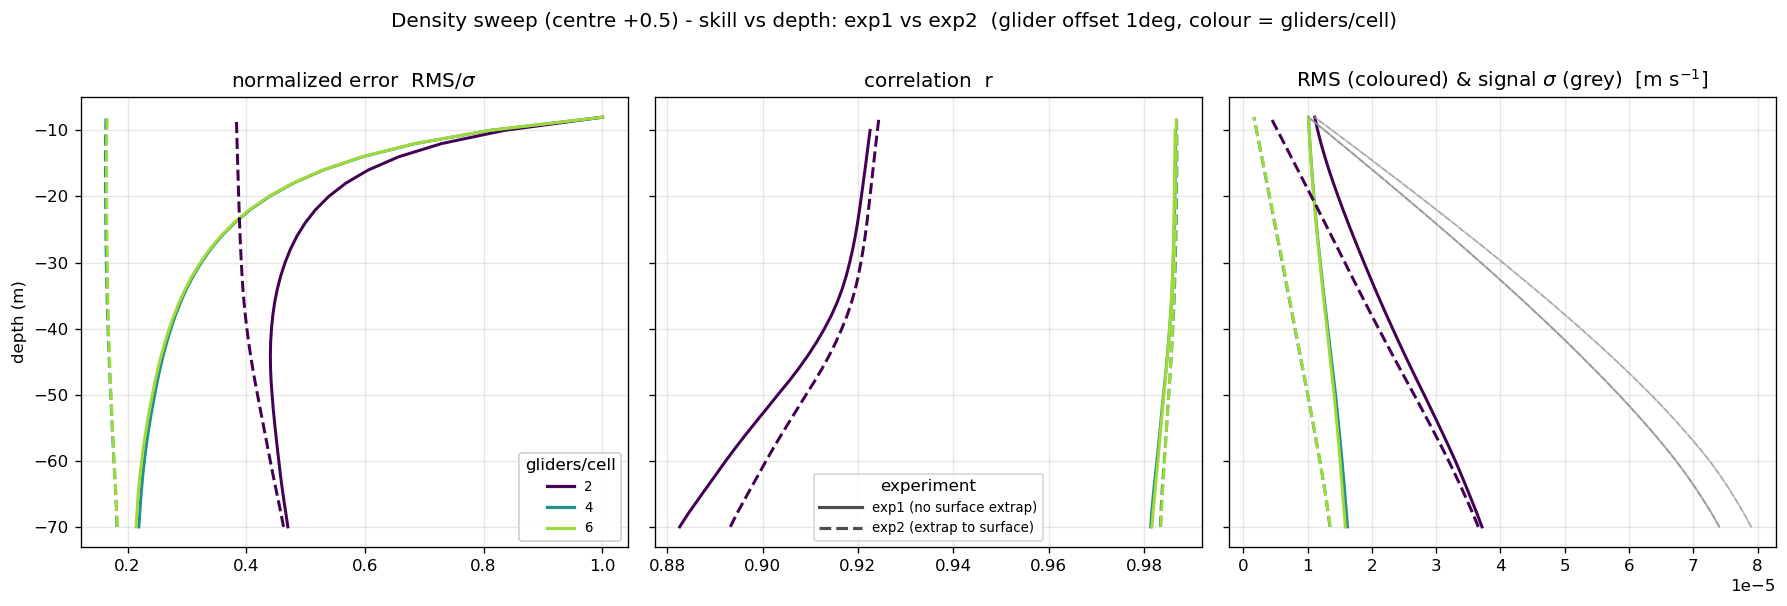

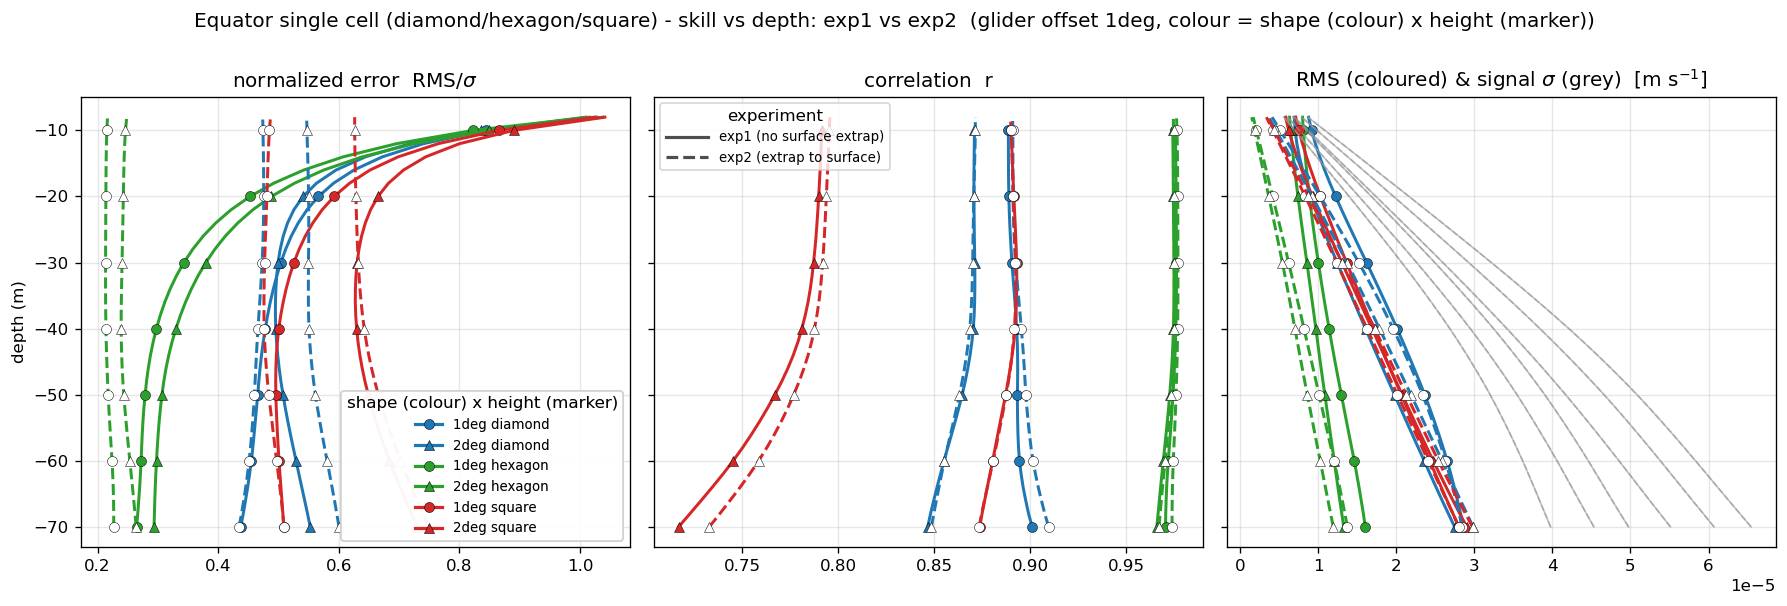

In [5]:
DEPTH_WIDTH = 1.0

def _depth_compare(rows_by_exp, tag, title, leg_title, line_handles):
    """Overlay depth profiles for both experiments. rows_by_exp maps exp -> list of
    (metrics_row, style) with style keys color, lbl and optional mk (marker shape)."""
    fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
    for exp in (1, 2):
        est = EXP_STYLE[exp]
        for r, s in rows_by_exp[exp]:
            ds = load_cell(exp, r)
            B = ot.w_skill_by_depth(ds.w_est, ds.w_model).sortby("depth")
            z = B.depth
            common = dict(color=s["color"], ls=est["ls"], lw=1.8,
                          marker=s.get("mk"), markevery=5, ms=6, mec="k", mew=0.3,
                          mfc=mfc(exp, s["color"]))
            axes[0].plot(B.norm_rms, z, **common)
            axes[1].plot(B["corr"], z, **common)
            axes[2].plot(B.rms, z, **common)
            axes[2].plot(B.w_model_std, z, color="0.6", ls=est["ls"], lw=1.0, alpha=0.6)
    axes[0].set_title(r"normalized error  RMS/$\sigma$")
    axes[1].set_title("correlation  r")
    axes[2].set_title(r"RMS (coloured) & signal $\sigma$ (grey)  [m s$^{-1}$]")
    axes[0].set_ylabel("depth (m)")
    for ax in axes:
        ax.grid(alpha=0.3)
    leg1 = axes[0].legend(handles=line_handles, title=leg_title, fontsize=8, loc="best")
    axes[0].add_artist(leg1)
    axes[1].legend(handles=exp_handles(), **EXP_LEG)
    fig.suptitle(f"{title} - skill vs depth: exp1 vs exp2  (glider offset {DEPTH_WIDTH:g}deg, "
                 f"colour = {leg_title})", y=1.0)
    fig.tight_layout()
    fig.savefig(os.path.join(OUTDIR, f"fig{tag}_compare.png"), dpi=150, bbox_inches="tight")
    plt.show()

# 5a shift + 5b equator 3-cell: colour = cell centre latitude
for tag, pat, title in (("5a_shift", "shift", "Shift array (4 cells)"),
                        ("5b_equator3cell", "equator_3cell", "Equator 3-cell array")):
    rows_by_exp = {}
    for exp in (1, 2):
        d = M[exp][(M[exp].pattern == pat) & np.isclose(M[exp].width, DEPTH_WIDTH)]
        rows_by_exp[exp] = [(d[np.isclose(d.center_lat, lat)].iloc[0],
                             dict(color=LAT_COLORS[lat], lbl=f"{lat:+.1f}"))
                            for lat in sorted(d.center_lat.unique())]
    lats = sorted(M[1][M[1].pattern == pat].center_lat.unique())
    line_handles = [Line2D([0], [0], color=LAT_COLORS[l], lw=1.9, label=f"{l:+.1f}") for l in lats]
    _depth_compare(rows_by_exp, tag, title, "cell centre lat", line_handles)

# 5c density: colour = gliders-per-cell
rows_by_exp = {}
for exp in (1, 2):
    d = M[exp][(M[exp].family == "density") & np.isclose(M[exp].width, DEPTH_WIDTH)]
    rows_by_exp[exp] = [(d[d.n_gliders_cell == ng].iloc[0],
                         dict(color=GLIDER_COLORS[ng], lbl=f"{int(ng)}"))
                        for ng in sorted(d.n_gliders_cell.unique())]
ngs = sorted(M[1][M[1].family == "density"].n_gliders_cell.unique())
line_handles = [Line2D([0], [0], color=GLIDER_COLORS[ng], lw=1.9, label=f"{int(ng)}") for ng in ngs]
_depth_compare(rows_by_exp, "5c_density", "Density sweep (centre +0.5)", "gliders/cell", line_handles)

# 5d equator single: colour = height, marker = shape
rows_by_exp = {}
for exp in (1, 2):
    d = M[exp][np.isclose(M[exp].width, DEPTH_WIDTH)]
    rows_by_exp[exp] = [(d[d.pattern == pat].iloc[0],
                         dict(color=EQS_STYLE[pat]["color"], mk=EQS_STYLE[pat]["mk"],
                              lbl=EQS_STYLE[pat]["lbl"]))
                        for pat in EQS_PATS if (d.pattern == pat).any()]
line_handles = [Line2D([0], [0], color=EQS_STYLE[p]["color"], marker=EQS_STYLE[p]["mk"],
                       mec="k", mew=0.3, lw=1.9, label=EQS_STYLE[p]["lbl"]) for p in EQS_PATS]
_depth_compare(rows_by_exp, "5d_equator_single", "Equator single cell (diamond/hexagon/square)",
               "shape (colour) x height (marker)", line_handles)